In [ ]:
# mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install the recovery code's dependencies. NOT pypots itself — this project uses
!pip install -q datasets pygrinder tsdb h5py einops

In [ ]:
import torch
print(torch.cuda.is_available())
!nvidia-smi

True
Wed Jul 29 07:58:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+

In [ ]:
# Load the shared config
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/FreshRetailNet Demand Forecasting/src')

import config as cfg
cfg.check()


  RAW_TRAIN      59.5 MB  /content/drive/MyDrive/Colab Notebooks/FreshRetailNet Demand Forecasting/inputs/freshretailnet_train.parquet
  RAW_TEST        5.4 MB  /content/drive/MyDrive/Colab Notebooks/FreshRetailNet Demand Forecasting/inputs/freshretailnet_test.parquet
  RECOVERED     100.3 MB  /content/drive/MyDrive/Colab Notebooks/FreshRetailNet Demand Forecasting/inputs/recovered_demand_timesnet.parquet

config OK


True

In [ ]:
# Point Python at the recovery code and move into its working directory
PROJECT_ROOT = cfg.RECOVERY

import sys, os
sys.path.insert(0, PROJECT_ROOT)
os.chdir(f'{PROJECT_ROOT}/exp')
print('working dir:', os.getcwd())

working dir: /content/drive/MyDrive/Colab Notebooks/FreshRetailNet Demand Forecasting/Latent Demand Recovery/exp


In [ ]:
# 6. the recovery code check
import importlib, data.generate_data as gd
importlib.reload(gd)
print('recovery will read :', gd.TRAIN_DATA_PATH)
print('exists             :', os.path.exists(gd.TRAIN_DATA_PATH))

recovery will read : /content/drive/MyDrive/Colab Notebooks/FreshRetailNet Demand Forecasting/inputs/freshretailnet_train.parquet
exists             : True


In [ ]:
# Confirm which pypots each side will use
import pypots
print('notebook   :', pypots.__file__)

!python -c "import sys, os; sys.path.append(os.path.abspath('..')); import pypots; print('subprocess :', pypots.__file__)"

notebook   : /content/drive/MyDrive/Colab Notebooks/FreshRetailNet Demand Forecasting/Latent Demand Recovery/pypots/__init__.py
subprocess : /content/drive/MyDrive/Colab Notebooks/FreshRetailNet Demand Forecasting/Latent Demand Recovery/pypots/__init__.py


In [ ]:
# data and model loaders.
from data import load_data
from model import load_model

cuda:0


In [ ]:
# load the full hourly dataset

CONFIG = {
    'model': 'TimesNet', 'saving_path': './save',
    'EPOCHS': 2, 'batch_size': 16, 'patience': 2,
    'n_layers': 2, 'd_model': 64, 'd_ffn': 32,
    'dropout': 0., 'lr': 0.001, 'weight_decay': 1e-5,
    'OT': 1, 'missing_rate': 0.0,
}
data = load_data(CONFIG)
CONFIG.update(data['params'])
print(data['train_set']['X'].shape)

0
(150000, 480, 6)


In [ ]:
# 9. sample model test

N = 32
sample_train_set = {'X': data['train_set']['X'][:N]}

model = load_model(CONFIG)
model.fit(sample_train_set)

2026-07-29 08:00:48 [INFO]: Using the given device: cuda:0
2026-07-29 08:00:48 [INFO]: Model files will be saved to ./save/TimesNet/20260729_T080048
2026-07-29 08:00:48 [INFO]: Tensorboard file will be saved to ./save/TimesNet/20260729_T080048/tensorboard
2026-07-29 08:00:48 [INFO]: TimesNet initialized with the given hyperparameters, the number of trainable parameters: 1,354,438
2026-07-29 08:00:51 [INFO]: Epoch 001 - training loss: 0.1056
2026-07-29 08:00:51 [INFO]: Epoch 002 - training loss: 0.0962
2026-07-29 08:00:51 [INFO]: Finished training. The best model is from epoch#2.
2026-07-29 08:00:51 [INFO]: Saved the model to ./save/TimesNet/20260729_T080048/TimesNet.pypots


In [ ]:
# sample test
results = model.predict(sample_train_set)
print(results['imputation'].shape)
print(results['imputation'][0, :10, 0])

(32, 480, 6)
[ 0.          0.          0.5         0.00634593 -0.00934623 -0.04241401
 -0.07055767 -0.07007693 -0.04405752  0.009028  ]


In [ ]:
# data prep
import numpy as np
import pandas as pd

target_orig = sample_train_set['X'][:, :, 0]
target_pred = results['imputation'][:, :, 0]

target_orig_daily = target_orig.reshape(-1, 30, 16)
pred_daily = target_pred.reshape(-1, 30, 16)

pred_daily = np.where(pred_daily > 0, pred_daily, 0)
missing_mask = np.isnan(target_orig_daily)

series_idx, day_idx = None, None
for i in range(missing_mask.shape[0]):
    for d in range(missing_mask.shape[1]):
        if missing_mask[i, d].any():
            series_idx, day_idx = i, d
            break
    if series_idx is not None:
        break

if series_idx is None:
    print("No stockout hours found in this 32-series sample - showing series 0, day 0 instead (nothing censored here).")
    series_idx, day_idx = 0, 0

print(f"series {series_idx}, day {day_idx}")

df = pd.DataFrame({
    'hour': range(6, 22),                                        # data only covers 6am-10pm
    'censored_input': target_orig_daily[series_idx, day_idx],     # NaN = stockout hour
    'was_stockout': missing_mask[series_idx, day_idx],
    'recovered_output': np.round(pred_daily[series_idx, day_idx], 3),
})
df

series 0, day 0


,hour,censored_input,was_stockout,recovered_output
0,6,0.0,False,0.000
1,7,0.0,False,0.000
2,8,0.5,False,0.500
3,9,NaN,True,0.006
4,10,NaN,True,0.000
5,11,NaN,True,0.000
6,12,NaN,True,0.000
7,13,NaN,True,0.000
8,14,NaN,True,0.000
9,15,NaN,True,0.009


In [ ]:
# recovery model
!python app.py --model TimesNet

cuda:0
Namespace(model='TimesNet', missing_rate=0.0)
0
2026-07-29 08:01:27 [INFO]: Using the given device: cuda:0
2026-07-29 08:01:27 [INFO]: Model files will be saved to ./save/TimesNet/20260729_T080127
2026-07-29 08:01:27 [INFO]: Tensorboard file will be saved to ./save/TimesNet/20260729_T080127/tensorboard
2026-07-29 08:01:27 [INFO]: TimesNet initialized with the given hyperparameters, the number of trainable parameters: 1,354,438
2026-07-29 08:34:39 [INFO]: Epoch 001 - training loss: 0.0626
2026-07-29 09:09:13 [INFO]: Epoch 002 - training loss: 0.0609
2026-07-29 09:43:56 [INFO]: Epoch 003 - training loss: 0.0605
2026-07-29 10:18:49 [INFO]: Epoch 004 - training loss: 0.0603
2026-07-29 10:56:32 [INFO]: Epoch 005 - training loss: 0.0602
2026-07-29 10:56:32 [INFO]: Finished training. The best model is from epoch#5.
2026-07-29 10:56:32 [INFO]: Saved the model to ./save/TimesNet/20260729_T080127/TimesNet.pypots
             method  decoupling score
0       sale_amount         -0.566447
1

In [ ]:
# Rebuild the daily table from the saved imputation, and score the recovery.

import numpy as np
from app import _demand_recovery, evaluation_decoupling

imputation = np.load('./demand/TimesNet_imputation_0.0.npy')
demand_df = _demand_recovery(imputation)
evaluation_decoupling(demand_df)

             method  decoupling score
0       sale_amount         -0.566447
1  sale_amount_pred          0.072971


In [ ]:
# evaluation - the controlled MNAR benchmark.


!python app.py --model TimesNet --missing_rate 0.3

cuda:0
Namespace(model='TimesNet', missing_rate=0.3)
9163425
2026-07-29 11:29:14 [INFO]: Using the given device: cuda:0
2026-07-29 11:29:14 [INFO]: Model files will be saved to ./save/TimesNet/20260729_T112914
2026-07-29 11:29:14 [INFO]: Tensorboard file will be saved to ./save/TimesNet/20260729_T112914/tensorboard
2026-07-29 11:29:15 [INFO]: TimesNet initialized with the given hyperparameters, the number of trainable parameters: 1,354,438
2026-07-29 12:02:31 [INFO]: Epoch 001 - training loss: 0.0643
2026-07-29 12:37:05 [INFO]: Epoch 002 - training loss: 0.0626
2026-07-29 13:11:52 [INFO]: Epoch 003 - training loss: 0.0622
2026-07-29 13:47:18 [INFO]: Epoch 004 - training loss: 0.0620
2026-07-29 14:24:40 [INFO]: Epoch 005 - training loss: 0.0619
2026-07-29 14:24:40 [INFO]: Finished training. The best model is from epoch#5.
2026-07-29 14:24:40 [INFO]: Saved the model to ./save/TimesNet/20260729_T112914/TimesNet.pypots
wape 0.27643938172076915
wpe 0.016240113069394633


In [ ]:
# Reload the raw data for the validation checks below
from data import load_train_data

In [ ]:
# 16. Validation of recovered data
import numpy as np
import pandas as pd
import os


train_df = load_train_data()
train_df = train_df.sort_values(by=['store_id', 'product_id', 'dt'])

horizon = 90
series_num = train_df.shape[0] // horizon

hours_sale = np.array(train_df['hours_sale'].tolist())
hours_stock_status = np.array(train_df['hours_stock_status'].tolist())

hours_sale_origin = hours_sale.reshape(series_num * 3, 30, 24)[..., 6:22]
stock_status_622  = hours_stock_status.reshape(series_num * 3, 30, 24)[..., 6:22]

recovered = np.load('./demand/TimesNet_imputation_0.0.npy')
recovered = recovered.reshape(-1, 30, 16)

in_stock = (stock_status_622 == 0)
out = ~in_stock

print("shapes:", hours_sale_origin.shape, stock_status_622.shape, recovered.shape)
assert hours_sale_origin.shape == stock_status_622.shape == recovered.shape


diff_in_stock = np.abs(recovered[in_stock] - hours_sale_origin[in_stock])
print("Check 1 - max diff where in-stock:", diff_in_stock.max())
if diff_in_stock.max() > 1e-3:
    print("WARNING: observed hours were altered more than expected - investigate before trusting downstream results.")
else:
    print("Check 1 PASSED: observed hours are untouched (within float precision).")


rec_out = recovered[out]
raw_out = hours_sale_origin[out]
print("\nCheck 2 - any negative recovered values:", (rec_out < 0).any())
print("Check 2 - any NaN recovered values:", np.isnan(rec_out).any())
print("Check 2 - fraction where recovered > censored raw value:", (rec_out > raw_out).mean())
print("Check 2 - max recovered during stockout:", rec_out.max(), "| 99th pct of all raw sales:", np.quantile(hours_sale_origin, 0.99))

changed = (np.abs(recovered - hours_sale_origin) > 1e-3).sum()
stockout_hours = out.sum()
print(f"\nCheck 3 - changed values: {changed}, stockout hours: {stockout_hours}")

reload_df = pd.read_parquet('./demand/demand.parquet')
print("\nCheck 4 - row count match:", reload_df.shape[0] == train_df.shape[0],
      "->", reload_df.shape[0], "vs", train_df.shape[0])
print(reload_df[['sale_amount', 'sale_amount_pred']].describe())


shapes: (150000, 30, 16) (150000, 30, 16) (150000, 30, 16)
Check 1 - max diff where in-stock: 3.8146972691777137e-07
Check 1 PASSED: observed hours are untouched (within float precision).

Check 2 - any negative recovered values: False
Check 2 - any NaN recovered values: False
Check 2 - fraction where recovered > censored raw value: 0.9035146192554034
Check 2 - max recovered during stockout: 4.0898757 | 99th pct of all raw sales: 0.6

Check 3 - changed values: 12702791, stockout hours: 14311536

Check 4 - row count match: True -> 4500000 vs 4500000
        sale_amount  sale_amount_pred
count  4.500000e+06      4.500000e+06
mean   9.985913e-01      1.203300e+00
std    1.406738e+00      1.676308e+00
min    0.000000e+00      0.000000e+00
25%    4.000000e-01      5.000000e-01
50%    7.000000e-01      8.000000e-01
75%    1.100000e+00      1.334507e+00
max    4.490000e+01      4.971386e+01


Found 1498616 (series, day) pairs with a partial stockout


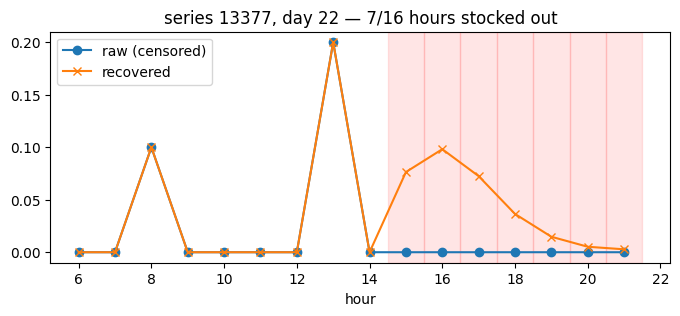

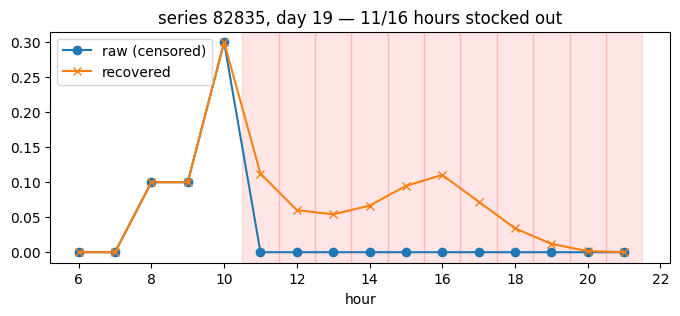

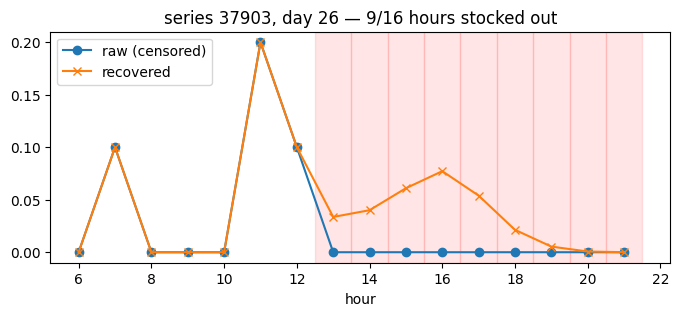

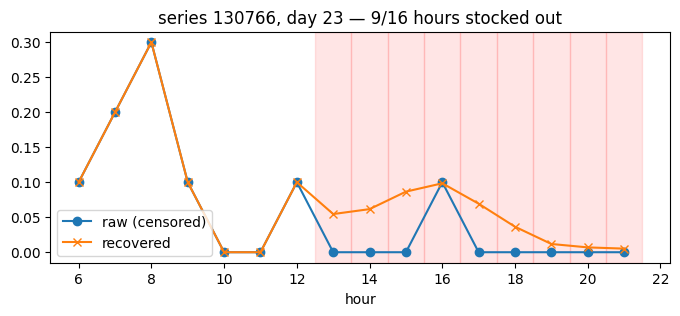

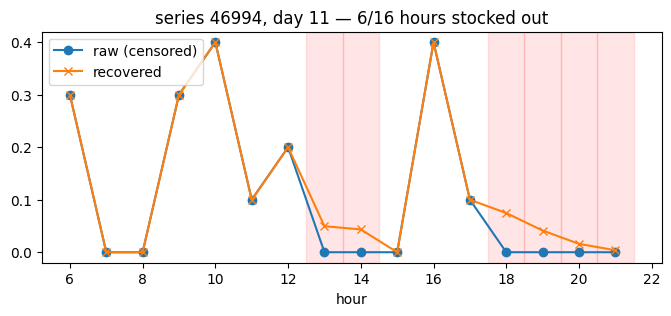

In [ ]:
# partial stockouts, where recovery is most visible.

import numpy as np
import matplotlib.pyplot as plt

# stockout count per (series, day) - how many of the 16 hours were stockout
stockout_count_per_day = out.sum(axis=2)   # shape (n_series, 30)

# "partial" = some hours missing, but not the whole day (avoid near-0 or near-full cases)
partial_mask = (stockout_count_per_day > 2) & (stockout_count_per_day < 14)
partial_indices = np.argwhere(partial_mask)   # list of [series_idx, day_idx] pairs

print(f"Found {len(partial_indices)} (series, day) pairs with a partial stockout")

# pick 5 at random for variety, rather than the most extreme cases
rng = np.random.default_rng(seed=1024)
chosen = partial_indices[rng.choice(len(partial_indices), size=5, replace=False)]

for s, day in chosen:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(range(6, 22), hours_sale_origin[s, day], label='raw (censored)', marker='o')
    ax.plot(range(6, 22), recovered[s, day], label='recovered', marker='x')
    stockout_hrs = np.where(out[s, day])[0] + 6
    for h in stockout_hrs:
        ax.axvspan(h - 0.5, h + 0.5, color='red', alpha=0.1)
    ax.set_title(f"series {s}, day {day} — {stockout_count_per_day[s, day]}/16 hours stocked out")
    ax.set_xlabel("hour")
    ax.legend()
    plt.show()

In [ ]:
# recovery stage output

import pandas as pd
demand_df = pd.read_parquet(f'{PROJECT_ROOT}/exp/demand/demand.parquet')
print(demand_df.columns.tolist())
print(demand_df[['sale_amount', 'sale_amount_pred']].describe())

['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level', 'sale_amount_pred']
        sale_amount  sale_amount_pred
count  4.500000e+06      4.500000e+06
mean   9.985913e-01      1.203300e+00
std    1.406738e+00      1.676308e+00
min    0.000000e+00      0.000000e+00
25%    4.000000e-01      5.000000e-01
50%    7.000000e-01      8.000000e-01
75%    1.100000e+00      1.334507e+00
max    4.490000e+01      4.971386e+01


In [ ]:
# End-to-end validation of the recovered demand

d     = pd.read_parquet(f'{PROJECT_ROOT}/exp/demand/demand.parquet')
clean = d[d.stock_hour6_22_cnt == 0]
diff  = (clean.sale_amount_pred - clean.sale_amount).abs()

print('no-stockout days   :', f'{len(clean):,}')
print('max difference     :', diff.max())
print('mean difference    :', diff.mean())
print('fraction identical :', (diff < 1e-6).mean().round(4))

no-stockout days   : 2,507,994
max difference     : 7.033348055074384e-07
mean difference    : 1.580376394240413e-08
fraction identical : 1.0


In [ ]:
# copy the recovered demand table into inputs/.
import shutil, os, pandas as pd

SRC  = f'{PROJECT_ROOT}/exp/demand/demand.parquet'
DEST = f'{cfg.INPUTS}/recovered_demand_timesnet.parquet'
os.makedirs(cfg.INPUTS, exist_ok=True)
shutil.copy(SRC, DEST)

a, b = pd.read_parquet(SRC), pd.read_parquet(DEST)
print('rows    :', f'{len(b):,}', '| match:', len(a) == len(b))
print('columns :', list(a.columns) == list(b.columns))
print('values  :', bool(a.sale_amount_pred.equals(b.sale_amount_pred)))
print('saved to:', DEST)

rows    : 4,500,000 | match: True
columns : True
values  : True
saved to: /content/drive/MyDrive/Colab Notebooks/FreshRetailNet Demand Forecasting/inputs/recovered_demand_timesnet.parquet
